# Figure 11.

| Author  | Stanley A. Baronett  |
|---------|----------------------|
| Created |  03/04/2026          |
| Updated |  03/04/2026          |

Similar to Figure 3, except the upper panel only shows grid resolutions at $1024^2$, and the lower panel shows them as dashed lines along with faded line styles for $512^2$.

In [1]:
#===============================================================================
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.axes_grid1 import AxesGrid
import numpy as np
import pandas as pd

root = '..'
reses = [512, 1024]
res = reses[-1]
n_p = 'np1'
runs = {
    f'dust_particles/{n_p}': {
        'ls': 'dotted',
        'codes' : {
            'Athena':       'tab:green',
            'Athena++':     'tab:red',
            'Pencil':       'tab:blue',
            'PLUTO':        'tab:pink'
        }
    },
    'dust_fluid': {
        'ls': 'solid',
        'codes' : {
            'Athena++':     'tab:purple',
            'FARGO3D':      'tab:olive',
            'Idefix':       'tab:orange',
            'LA-COMPASS':   'tab:cyan',
            'PLUTO':        'tab:brown'
        }
    }
}

512² Athena samples
	  Total: 10001
	Strided: 667
	Per 10T: 1000
512² Athena++ samples
	  Total: 2000
	Strided: 667
	Per 10T: 222
512² Pencil samples
	  Total: 2925
	Strided: 732
	Per 10T: 292
512² PLUTO samples
	  Total: 1002
	Strided: 1002
	Per 10T: 111
512² Athena++ samples
	  Total: 100014
	Strided: 630
	Per 10T: 10001
512² FARGO3D samples
	  Total: 631
	Strided: 631
	Per 10T: 63
512² Idefix samples
	  Total: 1002
	Strided: 1002
	Per 10T: 100
512² LA-COMPASS samples
	  Total: 31401
	Strided: 629
	Per 10T: 3489
512² PLUTO samples
	  Total: 1001
	Strided: 1001
	Per 10T: 100
1024² Athena samples
	  Total: 10001
	Strided: 667
	Per 10T: 1000
1024² Athena++ samples
	  Total: 2000
	Strided: 667
	Per 10T: 222
1024² Pencil samples
	  Total: 5508
	Strided: 689
	Per 10T: 550
1024² PLUTO samples
	  Total: 1002
	Strided: 501
	Per 10T: 111
1024² Athena++ samples
	  Total: 100014
	Strided: 630
	Per 10T: 10001
1024² FARGO3D samples
	  Total: 628
	Strided: 628
	Per 10T: 69
1024² Idefix samples
	  T

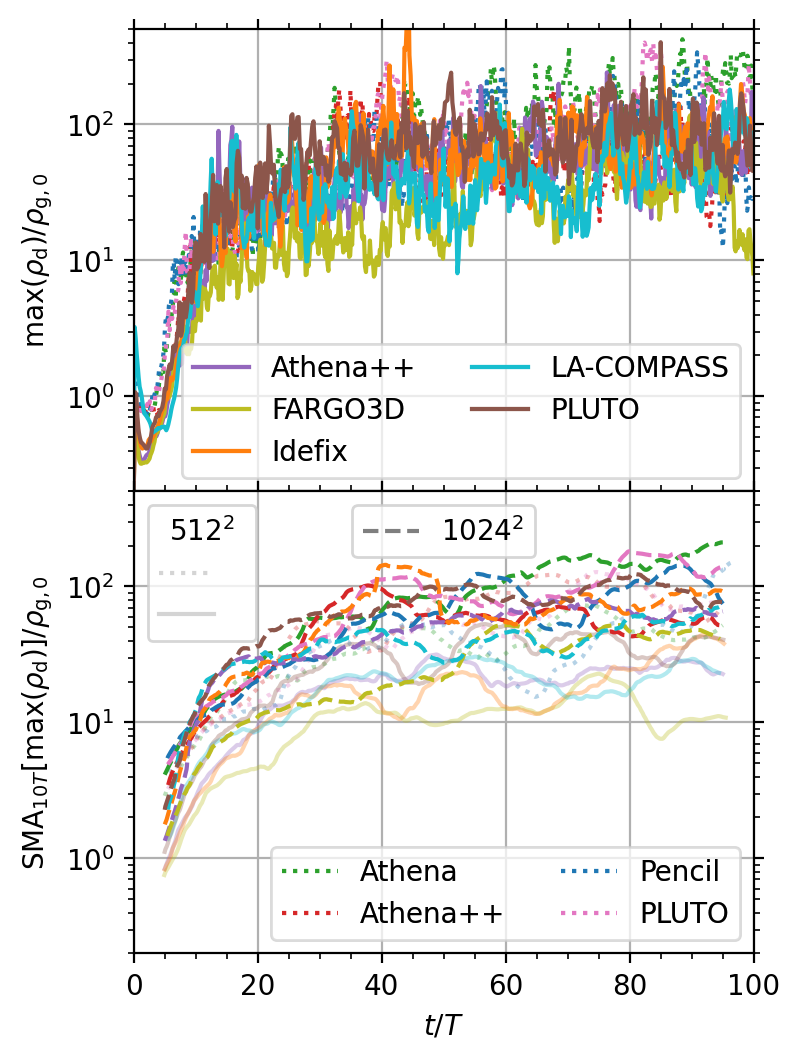

In [2]:
#===============================================================================
def print_samples(res, code, t, step, dt, window):
    """Print the number of samples in the time series."""
    print(f'{res}² {code} samples\n=======================')
    print(f'\t  Total: {len(t)}')
    print(f'\tStrided: {len(t[::step])}')
    print(f'\tPer {dt}T: {window}')

diag = True
dt = 10  # [T]

# Lowest cadence
path = f'../{res}/src/dust_fluid/FARGO3D'
n_min = len(np.load(f'{path}/time_series.npz')['t'])

# Plot
fig, axs = plt.subplots(nrows=2, sharex=True, figsize=(4, 6), dpi=200)
c_handles, ls_handles1, ls_handles2 = [[], []], [], []
for res in reses:
    for k, (key, value) in enumerate(runs.items()):
        for code, color in value['codes'].items():
            path = f'{root}/{res}/src/{key}/{code}'
            data = np.load(f'{path}/time_series.npz')
            t = data['t']
            step = len(t)//n_min
            if res == 512:
                alpha = 0.33
                ls = value['ls']
                c_handles[k].append(axs[k].plot([],[], c=color, label=code,
                                                ls=ls)[0])
            else:
                alpha = 1.0
                ls = 'dashed'
                # Strided
                if step < 2:
                    step = 1 if len(t)%n_min/n_min < 0.5 else 2
                try:
                    axs[0].plot(t[::step], data['maxrhod'][::step], alpha=alpha,
                                c=color, ls=value['ls'])
                except KeyError:
                    print(code)
            # SMA
            window = len(t)//int(t[-1]/dt)
            print_samples(res, code, t, step, dt, window) if diag else None
            df = pd.DataFrame(data=data['maxrhod'], index=t)
            df['sma'] = df.rolling(window, center=True).mean()
            axs[1].plot(df['sma'], alpha=alpha, c=color, ls=ls)

# Custom legends
ls_handles1.append(axs[1].plot([], [], alpha=0.33, c='tab:gray', ls='dotted',
                  label=' ')[0])
ls_handles1.append(axs[1].plot([], [], alpha=0.33, c='tab:gray', ls='solid',
                  label=' ')[0])
axs[1].add_artist(axs[1].legend(handles=ls_handles1, loc='upper left',
                  title=r'$512^2$'))
ls_handles2.append(axs[1].plot([], [], c='tab:gray', ls='dashed',
                  label=r'$1024^2$')[0])
axs[1].add_artist(axs[1].legend(handles=ls_handles2, loc='upper center'))

# Format plots
for k, ax in enumerate(axs):
    ax.add_artist(ax.legend(framealpha=0.5, handles=c_handles[k-1],
                            loc='lower right', ncol=2))
    ax.grid()
    ax.minorticks_on()
    ax.set(yscale='log')
    ax.tick_params(axis='both', which='both', top=True, right=True)
axs[0].set(ylabel=rf'$\max(\rho_\mathrm{{d}})/\rho_\mathrm{{g,0}}$', ylim=(2e-1, 5e2))
axs[1].set(xlabel=r'$t/T$', xlim=(0, 100), ylim=(2e-1, 5e2),
           ylabel=rf'$\mathrm{{SMA}}_{{{dt}T}}[\max(\rho_\mathrm{{d}})]/\rho_\mathrm{{g,0}}$')
fig.subplots_adjust(hspace=0)